In [ ]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv('/content/globalterrorismdb_0617dist.csv.zip', encoding='latin1')

/tmp/ipykernel_916/3286920306.py:1: DtypeWarning: Columns (4,6,31,33,53,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/globalterrorismdb_0617dist.csv.zip', encoding='latin1')


The goal for the my capstone was to understand what month of the year is the pattern of terorist attack most likely to happen.

In [ ]:
list(df.columns)

['eventid',
 'iyear',
 'imonth',
 'iday',
 'approxdate',
 'extended',
 'resolution',
 'country',
 'country_txt',
 'region',
 'region_txt',
 'provstate',
 'city',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'location',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'alternative_txt',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype1_txt',
 'attacktype2',
 'attacktype2_txt',
 'attacktype3',
 'attacktype3_txt',
 'targtype1',
 'targtype1_txt',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'targtype2',
 'targtype2_txt',
 'targsubtype2',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2',
 'natlty2_txt',
 'targtype3',
 'targtype3_txt',
 'targsubtype3',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 

In [ ]:
df.rename(columns={'iyear':'year', 'imonth':'month', 'iday': 'day','attacktype1': 'attack', 'targtype1': 'target' })

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
pd.set_option('display.max_row', None)
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,162886
extended,0
resolution,168131
country,0
country_txt,0
region,0


In [ ]:
df = df.rename(columns={'iyear': 'year', 'imonth': 'month', 'iday': 'day',
                        'attacktype1': 'attack', 'targtype1': 'target'})

df = df[['year', 'month', 'day', 'country', 'region', 'attack', 'target']]
df.head()

,year,month,day,country,region,attack,target
0,1970,7,2,58,2,1,14
1,1970,0,0,130,1,6,7
2,1970,1,0,160,5,1,10
3,1970,1,0,78,8,3,7
4,1970,1,0,101,4,7,7


In [ ]:
df - df[df['month'] !=0]

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df['year'].min(), df['year'].max()

(1970, 2016)

In [ ]:
df = df[df['year'] > df['year'].max() - 10]
df['year'].min(), df['year'].max()

(2007, 2016)

In [ ]:
df.head(3)

,year,month,day,country,region,attack,target
81998,2007,1,1,155,10,6,10
81999,2007,1,1,205,5,3,14
82000,2007,1,1,186,6,3,4


In [ ]:
df = df.drop(columns=['day','country','region','attack','target'] )

In [ ]:
df.head(3)

,year,month
81998,2007,1
81999,2007,1
82000,2007,1


In [ ]:
y= df['year']
X= df['month']

# check how many rows I have first

In [ ]:
len(df)

88352

# Minimizing the amount of rows I will use for testing

In [ ]:
df_small = df.sample(20000, random_state=42)

# Changing my feature back to its normal name

In [ ]:
df_small = df

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

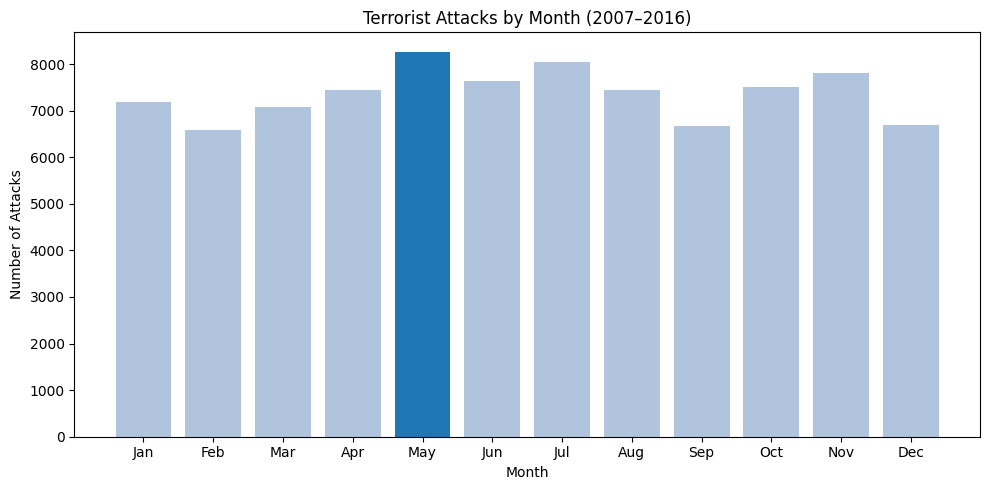

In [ ]:
import matplotlib.pyplot as plt

counts = df['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

colors = ['#1f77b4' if c == counts.max() else '#b0c4de' for c in counts]

plt.figure(figsize=(10, 5))
plt.bar(month_names, counts.values, color=colors)
plt.title('Terrorist Attacks by Month (2007–2016)')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()